In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # 로지스틱은 수치 표준화가 중요합니다
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [2]:
# 1. 데이터 로드
try:
    df = pd.read_csv('raw_data_with_gmt.csv', nrows=200000)
except UnicodeDecodeError:
    df = pd.read_csv('raw_data_with_gmt.csv', nrows=200000)
print(f"데이터 셰이프: {df.shape}")

데이터 셰이프: (200000, 81)


C:\Users\USER\AppData\Local\Temp\ipykernel_1144\4162819910.py:3: DtypeWarning: Columns (1,2,3,4,5,7,8,9,27,28,29,30,31,32,39,40,41,42,43,50,52,53,54,56,66,67,68,69,70,71,72,73,74,75,76,77,78,80) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('raw_data_with_gmt.csv', nrows=200000)


In [3]:
df.head() # 데이터 구조 확인
# print("전체 컬럼 리스트:")
# print(df.columns.tolist())

# 데이터 구조 및 타입 확인 (메모리 사용량 포함)
# print("\n데이터 정보 요약:")
# df.info(verbose=True, show_counts=True)

,event_name,event_date,event_timestamp,event_value_in_usd,event_bundle_sequence_id,stream_id,platform,user_pseudo_id,user_first_touch_timestamp,revenue,...,param_ga_session_number,param_percent_scrolled,param_unique_search_term,param_session_engaged,param_tax,param_transaction_id,param_value,offset_minutes,GMT,hour_gmt
0,add_to_cart,20210105,1609842048718708,NaN,-6684633987,2100450278,WEB,11687414.588464,1609842012544247.0,0,...,1,NaN,NaN,1.0,NaN,NaN,NaN,-300,UTC-05:00,5
1,view_item,20210105,1609875454872772,NaN,-8841956441,2100450278,WEB,22782175.058082,1607971368782953.0,0,...,8,NaN,NaN,1.0,NaN,NaN,NaN,120,UTC+02:00,21
2,view_item,20201118,1605715145448449,NaN,-1270321649,2100450278,WEB,1661274.639968,1605677740627483.0,0,...,2,NaN,NaN,1.0,NaN,NaN,NaN,420,UTC+07:00,22
3,user_engagement,20201117,1605615971850044,NaN,-2213072406,2100450278,WEB,8569675.440999,1605615890433235.0,0,...,1,NaN,NaN,1.0,NaN,NaN,NaN,-300,UTC-05:00,7
4,view_promotion,20201110,1604996338725057,NaN,6028570973,2100450278,WEB,2298657.21183,1597015774869512.0,0,...,10,NaN,NaN,0.0,NaN,NaN,NaN,-360,UTC-06:00,2


In [4]:
# 1-1 Step 1: 이벤트 단위 정제
# event_timestamp + event_name 기준으로 pivot
# event_df = df.pivot_table(
#     index=["event_timestamp", "event_name"],
#     columns="event_params.key",
#     values="event_params.value.string_value",
#     aggfunc="first"
# ).reset_index()

# 1) 타입 정리: event_date / event_timestamp
# event_date가 YYYYMMDD 형태라면 (가장 흔함)
df["event_date"] = pd.to_datetime(df["event_date"].astype(str), format="%Y%m%d", errors="coerce")
df["event_timestamp"] = pd.to_numeric(df["event_timestamp"], errors="coerce")

# event_time 생성/정리
if "event_time" in df.columns:
    df["event_time"] = pd.to_datetime(df["event_time"], errors="coerce")
else:
    df["event_time"] = pd.to_datetime(df["event_timestamp"], unit="us", errors="coerce")

# 필수 컬럼 체크 + 결측 제거
required = ["user_pseudo_id", "event_timestamp", "event_name", "event_date"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"필수 컬럼 누락: {missing}")

df = df.dropna(subset=["user_pseudo_id", "event_timestamp", "event_name", "event_date"])


In [5]:
# 2) 이벤트 키 정의 (이벤트 1건을 유일하게 식별)
event_key = ["user_pseudo_id", "event_timestamp", "event_name"]
if "event_bundle_sequence_id" in df.columns:
    event_key.append("event_bundle_sequence_id")

In [6]:
# 3) 이벤트 수준 집계 규칙(존재하는 컬럼만)
# item이 있으면 한 이벤트가 item 개수만큼 늘어났을 수 있으므로 event_bundle_sequence_id까지 포함 권장

first_cols = [
    # 유저/환경
    "currency", "category", "platform", "stream_id",
    "mobile_brand_name", "mobile_model_name", "operating_system",
    "operating_system_version", "language", "browser", "browser_version",
    # geo
    "continent", "sub_continent", "country", "region", "city",
    # traffic source
    "medium", "name", "source",
    # page/캠페인
    "param_campaign", "param_medium", "param_source", "param_term",
    "param_page_location", "param_page_referrer", "param_page_title",
    "param_payment_type", "param_promotion_name", "param_search_term",
    "param_shipping_tier", "param_coupon",
]

sum_cols = [
    "event_value_in_usd", "revenue",
    "purchase_revenue_in_usd", "purchase_revenue",
    "tax_value_in_usd", "tax_value",
    "total_item_quantity", "unique_items",
    "item_revenue", "price_in_usd",
]

max_cols = [
    "param_engagement_time_msec", "param_percent_scrolled",
    "param_ga_session_id", "param_ga_session_number",
    "param_session_engaged",
]

# 실제 df에 존재하는 컬럼만 집계에 포함
agg = {}
for c in first_cols:
    if c in df.columns:
        agg[c] = "first"
for c in sum_cols:
    if c in df.columns:
        agg[c] = "sum"
for c in max_cols:
    if c in df.columns:
        agg[c] = "max"

# 아이템 관련(이벤트가 아이템별로 여러 행이면 1행으로 압축하면서 요약)
if "item_id" in df.columns:
    agg["item_id"] = pd.Series.nunique
    # agg["item_line_count"] = ("item_id", "count")  # 아이템 라인 수(확장 정도)
if "item_name" in df.columns:
    agg["item_name"] = pd.Series.nunique
if "item_brand" in df.columns:
    agg["item_brand"] = pd.Series.nunique   # 총 아이템 라인 수(이벤트 확장 정도 확인/피처로도 활용)

In [7]:
# 4) 이벤트 단위로 압축
event_df = df.groupby(event_key, as_index=False).agg(agg)

# 대표 시간/날짜 복원
event_df["event_time"] = pd.to_datetime(event_df["event_timestamp"], unit="us", errors="coerce")
event_df["event_date"] = event_df["event_time"].dt.normalize()  # 00:00:00 기준 날짜
event_df.head()


,user_pseudo_id,event_timestamp,event_name,event_bundle_sequence_id,currency,category,platform,stream_id,mobile_brand_name,mobile_model_name,...,param_engagement_time_msec,param_percent_scrolled,param_ga_session_id,param_ga_session_number,param_session_engaged,item_id,item_name,item_brand,event_time,event_date
0,1000557.291184,1.610022e+15,page_view,6781584507,USD,mobile,WEB,2100450278,Apple,iPhone,...,4.0,NaN,2242291475,1,1.0,0,0,0,2021-01-07 12:15:38.549142,2021-01-07
1,1000631.119593,1.604675e+15,view_item,-76321058,USD,mobile,WEB,2100450278,Apple,iPhone,...,3725.0,NaN,2538888316,1,1.0,1,1,1,2020-11-06 14:59:11.446757,2020-11-06
2,1000631.119593,1.604675e+15,view_item,8567039887,USD,mobile,WEB,2100450278,Apple,iPhone,...,4100.0,NaN,2538888316,1,1.0,1,1,1,2020-11-06 14:59:55.482253,2020-11-06
3,1000684.096746,1.607364e+15,view_item,7595499902,USD,desktop,WEB,2100450278,Apple,Safari,...,2546.0,NaN,7101309994,1,1.0,1,1,1,2020-12-07 18:04:30.804304,2020-12-07
4,1000684.096746,1.607364e+15,select_item,6528849387,USD,desktop,WEB,2100450278,Apple,Safari,...,2101.0,NaN,7101309994,1,1.0,1,1,1,2020-12-07 18:07:51.124888,2020-12-07


In [8]:
# 5) 숫자형 안전 변환
def _to_num(s):
    return pd.to_numeric(s, errors="coerce").fillna(0)

for c in sum_cols + max_cols:
    if c in event_df.columns:
        event_df[c] = _to_num(event_df[c])

for c in first_cols:
    if c in event_df.columns:
        event_df[c] = event_df[c].fillna("UNKNOWN")

In [9]:
# 6) "진짜 이벤트" 플래그 (핵심)
event_df["is_purchase"] = (event_df["event_name"] == "purchase").astype(int)
event_df["is_page_view"] = (event_df["event_name"] == "page_view").astype(int)
event_df["is_add_to_cart"] = (event_df["event_name"] == "add_to_cart").astype(int)

# (옵션) purchase 보정: transaction/revenue로 purchase-like 추가
txn = event_df.get("transaction_id", pd.Series([np.nan]*len(event_df))).notna() | \
      event_df.get("param_transaction_id", pd.Series([np.nan]*len(event_df))).notna()

purchase_revenue = _to_num(event_df.get("purchase_revenue_in_usd", 0)) + _to_num(event_df.get("purchase_revenue", 0))
event_value = _to_num(event_df.get("event_value_in_usd", 0))
revenue = _to_num(event_df.get("revenue", 0))

event_df["is_purchase_like"] = (event_df["is_purchase"].eq(1) | txn | (purchase_revenue > 0) | (revenue > 0) | (event_value > 0)).astype(int)

print("raw rows:", len(df))
print("event rows:", len(event_df))
event_df.head()

raw rows: 199998
event rows: 189238


,user_pseudo_id,event_timestamp,event_name,event_bundle_sequence_id,currency,category,platform,stream_id,mobile_brand_name,mobile_model_name,...,param_session_engaged,item_id,item_name,item_brand,event_time,event_date,is_purchase,is_page_view,is_add_to_cart,is_purchase_like
0,1000557.291184,1.610022e+15,page_view,6781584507,USD,mobile,WEB,2100450278,Apple,iPhone,...,1.0,0,0,0,2021-01-07 12:15:38.549142,2021-01-07,0,1,0,0
1,1000631.119593,1.604675e+15,view_item,-76321058,USD,mobile,WEB,2100450278,Apple,iPhone,...,1.0,1,1,1,2020-11-06 14:59:11.446757,2020-11-06,0,0,0,0
2,1000631.119593,1.604675e+15,view_item,8567039887,USD,mobile,WEB,2100450278,Apple,iPhone,...,1.0,1,1,1,2020-11-06 14:59:55.482253,2020-11-06,0,0,0,0
3,1000684.096746,1.607364e+15,view_item,7595499902,USD,desktop,WEB,2100450278,Apple,Safari,...,1.0,1,1,1,2020-12-07 18:04:30.804304,2020-12-07,0,0,0,0
4,1000684.096746,1.607364e+15,select_item,6528849387,USD,desktop,WEB,2100450278,Apple,Safari,...,1.0,1,1,1,2020-12-07 18:07:51.124888,2020-12-07,0,0,0,0


In [10]:
print("raw df rows:", len(df))
print("event_date null:", df["event_date"].isna().sum())
print("event_timestamp null:", df["event_timestamp"].isna().sum())
print("event_name null:", df["event_name"].isna().sum())

raw df rows: 199998
event_date null: 0
event_timestamp null: 0
event_name null: 0


In [11]:
# 1-2 Step 2: user_id 붙이기
event_df["user_pseudo_id"] = df["user_pseudo_id"]
event_df.head()

,user_pseudo_id,event_timestamp,event_name,event_bundle_sequence_id,currency,category,platform,stream_id,mobile_brand_name,mobile_model_name,...,param_session_engaged,item_id,item_name,item_brand,event_time,event_date,is_purchase,is_page_view,is_add_to_cart,is_purchase_like
0,11687414.588464,1.610022e+15,page_view,6781584507,USD,mobile,WEB,2100450278,Apple,iPhone,...,1.0,0,0,0,2021-01-07 12:15:38.549142,2021-01-07,0,1,0,0
1,22782175.058082,1.604675e+15,view_item,-76321058,USD,mobile,WEB,2100450278,Apple,iPhone,...,1.0,1,1,1,2020-11-06 14:59:11.446757,2020-11-06,0,0,0,0
2,1661274.639968,1.604675e+15,view_item,8567039887,USD,mobile,WEB,2100450278,Apple,iPhone,...,1.0,1,1,1,2020-11-06 14:59:55.482253,2020-11-06,0,0,0,0
3,8569675.440999,1.607364e+15,view_item,7595499902,USD,desktop,WEB,2100450278,Apple,Safari,...,1.0,1,1,1,2020-12-07 18:04:30.804304,2020-12-07,0,0,0,0
4,2298657.21183,1.607364e+15,select_item,6528849387,USD,desktop,WEB,2100450278,Apple,Safari,...,1.0,1,1,1,2020-12-07 18:07:51.124888,2020-12-07,0,0,0,0


In [ ]:
# 1-3 Step 3: 유저 단위 집계

import pandas as pd
import numpy as np

CUTOFF = pd.to_datetime("2021-01-17")

def to_num(series, default=0):
    return pd.to_numeric(series, errors="coerce").fillna(default)

# ---------- 타입 정리 ----------
event_df["event_date"] = pd.to_datetime(event_df["event_date"], errors="coerce")

event_df["param_engagement_time_msec"] = to_num(event_df.get("param_engagement_time_msec", 0))
event_df["param_percent_scrolled"] = to_num(event_df.get("param_percent_scrolled", 0))
event_df["param_ga_session_id"] = to_num(event_df.get("param_ga_session_id", np.nan))
event_df["param_ga_session_number"] = to_num(event_df.get("param_ga_session_number", np.nan))

event_df["param_page_location"] = event_df.get("param_page_location", "").fillna("").astype(str)
event_df["param_search_term"] = event_df.get("param_search_term", np.nan)

# outbound 정규화
outbound_val = event_df.get("param_outbound", "")

# 만약 outbound_val이 Series가 아니라면(기본값 ""이 왔다면) 강제로 Series로 변환
if not isinstance(outbound_val, pd.Series):
    outbound_val = pd.Series([outbound_val] * len(event_df), index=event_df.index)
    
event_df["param_outbound_bool"] = (
    outbound_val
    .fillna("")      # 결측치 방어
    .astype(str)     # 이제는 안전하게 변환 가능
    .str.lower()
    .isin(["true", "1", "t", "yes"])
)

# ---------- 유저 단위 집계 ----------
user_feature_df = event_df.groupby("user_pseudo_id", as_index=False).agg(
    total_events=("event_timestamp", "count"),
    page_views=("is_page_view", "sum"),
    cart_count=("is_add_to_cart", "sum"),
    purchase_count=("is_purchase", "sum"),
    avg_engagement_time_msec=("param_engagement_time_msec", "mean"),
    last_event_date=("event_date", "max"),

    session_count=("param_ga_session_id", "nunique"),
    unique_pages=("param_page_location", "nunique"),
    avg_session_number=("param_ga_session_number", "mean"),
    scroll50_cnt=("param_percent_scrolled", lambda s: (s >= 50).sum()),
    engaged_cnt=("param_engagement_time_msec", lambda s: (s > 0).sum()),
    outbound_cnt=("param_outbound_bool", "sum"),
    search_cnt=("param_search_term", lambda s: s.notna().sum()),
)

# ---------- recency ----------
user_feature_df["recency_days"] = (CUTOFF - user_feature_df["last_event_date"]).dt.days
user_feature_df["recency_days"] = user_feature_df["recency_days"].fillna(9999).astype(int)

# ---------- 파생 피처 ----------
user_feature_df["view_to_cart_rate"] = user_feature_df["cart_count"] / (user_feature_df["page_views"] + 1)

# ---------- 날짜 / ID 컬럼 제거 ----------
# user_feature_df = user_feature_df.drop(columns=["user_pseudo_id", "last_event_date"])


user_feature_df


,user_pseudo_id,total_events,page_views,cart_count,purchase_count,avg_engagement_time_msec,last_event_date,session_count,unique_pages,avg_session_number,scroll50_cnt,engaged_cnt,outbound_cnt,search_cnt,recency_days,view_to_cart_rate
0,1000557.291184,1,0,0,0,7437.000000,2020-11-13,1,1,1.000000,0,1,0,1,65,0.0
1,1000631.119593,2,0,0,0,53905.500000,2020-12-16,2,2,1.500000,1,2,0,2,32,0.0
2,1000684.096746,2,0,1,0,2.000000,2020-12-31,2,2,2.000000,0,1,0,2,17,1.0
3,1000985.471257,1,0,0,0,6633.000000,2020-12-18,1,1,1.000000,0,1,0,1,30,0.0
4,1001129.259814,1,0,1,0,1497.000000,2020-12-05,1,1,7.000000,0,1,0,1,43,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77709,99605019.1220829147,1,0,0,0,123.000000,2020-11-28,1,1,1.000000,0,1,0,1,50,0.0
77710,9963542.3978980993,3,0,1,0,7589.000000,2020-12-20,3,3,4.666667,0,3,0,3,28,1.0
77711,99809596.4037171335,1,0,0,0,0.000000,2020-11-13,1,1,1.000000,0,0,0,1,65,0.0
77712,99826321.7020196151,6,1,0,0,10865.333333,2021-01-25,6,5,1.333333,1,5,0,6,-8,0.0


In [13]:
user_feature_df.info() # user_pseudo_id, event_date 컬럼 없애기 및, 소수점 두자리까지만 출력하기 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77714 entries, 0 to 77713
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_pseudo_id            77714 non-null  object        
 1   total_events              77714 non-null  int64         
 2   page_views                77714 non-null  int32         
 3   cart_count                77714 non-null  int32         
 4   purchase_count            77714 non-null  int32         
 5   avg_engagement_time_msec  77714 non-null  float64       
 6   last_event_date           77714 non-null  datetime64[ns]
 7   session_count             77714 non-null  int64         
 8   unique_pages              77714 non-null  int64         
 9   avg_session_number        77714 non-null  float64       
 10  scroll50_cnt              77714 non-null  int64         
 11  engaged_cnt               77714 non-null  int64         
 12  outbound_cnt      

In [14]:
print("user_feature_df rows:", len(user_feature_df))

user_feature_df rows: 77714


In [15]:
# 1-4 Step 4: Label 생성

import pandas as pd
import numpy as np

cutoff_date = pd.to_datetime("2021-01-17")
start_date  = pd.to_datetime("2020-11-01")
end_date    = pd.to_datetime("2021-01-16")

obs_df = df[df['event_date'] < cutoff_date].copy()
rep_df = df[df['event_date'] >= cutoff_date].copy()

# 관측 기간 유저만 대상 (학습/예측 대상)
user_list = obs_df['user_pseudo_id'].unique()
label_df = pd.DataFrame({'user_pseudo_id': user_list})

# (A) churn: 리플레이 기간에 등장하면 active(=0), 아니면 churn(=1)
active_users = rep_df['user_pseudo_id'].unique()
label_df['is_churned'] = (~label_df['user_pseudo_id'].isin(active_users)).astype(int)

# (B) 전체기간(11/1~1/31) 구매 정답(is_actual_purchaser) 만들기
def to_num(s):
    return pd.to_numeric(s, errors="coerce").fillna(0)

df["revenue"] = to_num(df.get("revenue", 0))
df["purchase_revenue"] = to_num(df.get("purchase_revenue", 0))
df["purchase_revenue_in_usd"] = to_num(df.get("purchase_revenue_in_usd", 0))

all_purchase_mask = (
    (df["event_date"] >= start_date) &
    (df["event_date"] <= end_date) &
    (
        (df.get("revenue", 0) > 0) |
        (df.get("purchase_revenue", 0) > 0) |
        (df.get("purchase_revenue_in_usd", 0) > 0) |
        (df.get("transaction_id", pd.Series(index=df.index, dtype="object")).notna())
    )
)

all_purchasers = df.loc[all_purchase_mask, "user_pseudo_id"].unique()

full_label_df = pd.DataFrame({"user_pseudo_id": df["user_pseudo_id"].unique()})
full_label_df["is_actual_purchaser"] = full_label_df["user_pseudo_id"].isin(all_purchasers).astype(int)

# ✅ (필수) 학습 대상(label_df)에 전체기간 구매 정답 붙이기
label_df = label_df.merge(full_label_df, on="user_pseudo_id", how="left")
label_df["is_actual_purchaser"] = label_df["is_actual_purchaser"].fillna(0).astype(int)

# (C) 관측 기간 구매 라벨(기존 is_purchaser / is_repeat_purchaser)
# obs_df 숫자형 변환
for c in ["revenue", "purchase_revenue", "purchase_revenue_in_usd"]:
    if c in obs_df.columns:
        obs_df[c] = to_num(obs_df[c])

purchase_mask = (
    (obs_df.get("revenue", 0) > 0) |
    (obs_df.get("purchase_revenue", 0) > 0) |
    (obs_df.get("purchase_revenue_in_usd", 0) > 0) |
    (obs_df.get("transaction_id", pd.Series(index=obs_df.index, dtype="object")).notna())
)

# ✅ (필수) purchase_mask 사용
purchase_counts = obs_df[purchase_mask].groupby('user_pseudo_id').size()

label_df['purchase_count'] = label_df['user_pseudo_id'].map(purchase_counts).fillna(0).astype(int)
label_df['is_purchaser'] = (label_df['purchase_count'] >= 1).astype(int)
label_df['is_repeat_purchaser'] = (label_df['purchase_count'] >= 2).astype(int)

print("학습 대상 유저 수:", len(label_df))
print("전체기간 구매 정답(is_actual_purchaser) 비율:", label_df["is_actual_purchaser"].mean())
print("관측기간 구매 라벨(is_purchaser) 비율:", label_df["is_purchaser"].mean())
print("이탈 라벨(is_churned) 비율:", label_df["is_churned"].mean())


학습 대상 유저 수: 68222
전체기간 구매 정답(is_actual_purchaser) 비율: 0.4679282342939228
관측기간 구매 라벨(is_purchaser) 비율: 0.4679282342939228
이탈 라벨(is_churned) 비율: 0.9878045205358975


In [16]:
# 1-5 Step 5: 모델 학습
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

X = user_feature_df[["total_events", "page_views", "cart_count"]].fillna(0)
y = (user_feature_df["purchase_count"] >= 1).astype(int)

print(f"총 유저 수: {len(user_feature_df)}")
print(f"구매자 수(is_purchase > 0): {user_feature_df[user_feature_df['purchase_count'] > 0].shape[0]}")

# 만약 여기서 '총 유저 수'가 0이라면, event_df 자체가 비어있을 가능성이 큽니다.

# print("X shape:", X.shape)
# print("y distribution:\n", y.value_counts())
# print("NaN in X:\n", X.isnull().sum())
# print("NaN in y:", y.isnull().sum())
# print("X types:\n", X.dtypes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # 0과 1의 비율을 훈련/테스트에 골고루 배분
)
print(f"y_train의 값 분포:\n{y_train.value_counts()}")
# print(f"훈련셋 타겟 분포:\n{y_train.value_counts()}")
# print(f"테스트셋 타겟 분포:\n{y_test.value_counts()}")

# 로지스틱 회귀
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)




총 유저 수: 77714
구매자 수(is_purchase > 0): 404
y_train의 값 분포:
purchase_count
0    61848
1      323
Name: count, dtype: int64


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
# LGB
lgb_model = LGBMClassifier(
                n_estimators=100,          # 데이터가 적으니 나무를 조금만 심습니다.
                min_child_samples=1,       # 리프 노드에 데이터가 1개만 있어도 분할 허용
                min_data_in_bin=1,         # 히스토그램 빈(bin) 생성 시 최소 데이터 제한 해제
                verbose=-1                 # 불필요한 경고창 끄기
            )
lgb_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,1


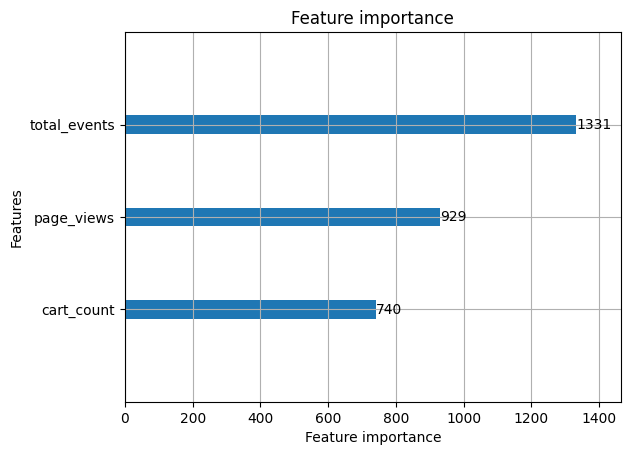

In [18]:
lgb.plot_importance(lgb_model)
plt.show()

In [19]:
!pip install catboost

In [20]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, fbeta_score
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier  # ✅ 추가

# CatBoost 준비: 설치되어 있으면 사용, 없으면 자동으로 제외
try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
except ModuleNotFoundError:
    HAS_CATBOOST = False
    print("CatBoost 미설치: 필요하면 `!pip install catboost` 후 런타임 재시작하세요.")

# -----------------------------
# 0) F0.5
# -----------------------------
def f05_score(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=0.5, zero_division=0)

THRESHOLDS = np.arange(0.05, 0.96, 0.05)

def best_threshold_by_f05(y_true, y_proba):
    best_thr, best_f05, best_pred = 0.5, -1.0, None
    for t in THRESHOLDS:
        pred = (y_proba >= t).astype(int)
        f05 = f05_score(y_true, pred)
        if f05 > best_f05:
            best_thr, best_f05, best_pred = t, f05, pred
    return best_thr, best_f05, best_pred

# -----------------------------
# 1) 하이퍼파라미터
# -----------------------------
CFG = {
    "Logistic": dict(max_iter=1000, class_weight="balanced"),
    "LightGBM": dict(n_estimators=300, learning_rate=0.05, min_child_samples=10, min_data_in_bin=1, verbose=-1, random_state=42),
    "XGBoost": dict(n_estimators=200, learning_rate=0.10, max_depth=5, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                    eval_metric="logloss", random_state=42, n_jobs=-1),
}

def calc_spw(y_train):
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    return (neg / pos) if pos > 0 else 1.0

def build_model(model_name, spw):
    if model_name == "Logistic":
        return LogisticRegression(**CFG["Logistic"])
    if model_name == "LightGBM":
        return LGBMClassifier(scale_pos_weight=spw, **CFG["LightGBM"])
    if model_name == "XGBoost":
        return XGBClassifier(scale_pos_weight=spw, **CFG["XGBoost"])
    if model_name == "CatBoost":
        # CatBoost는 class_weights 사용
        return CatBoostClassifier(
            iterations=500, learning_rate=0.10, depth=6,
            loss_function="Logloss", eval_metric="AUC",
            class_weights=[1.0, float(spw)],
            random_seed=42, verbose=False
        )
    raise ValueError(model_name)

# -----------------------------
# 2) X와 라벨(y) 준비 (merge로 정렬 보장)
# -----------------------------
data = user_feature_df.merge(
    label_df[["user_pseudo_id", "is_purchaser", "is_actual_purchaser"]],
    on="user_pseudo_id",
    how="inner"
)

# ✅ 누수 방지: 라벨/ID/구매카운트/날짜형 제거
DROP_COLS = {
    "user_pseudo_id",
    "is_purchaser",
    "is_actual_purchaser",
    "purchase_count",          # 있으면 반드시 제거(정답 힌트)
    "is_repeat_purchaser",     # 있으면 제거
    "last_event_date"          # 있으면 제거(날짜 raw)
}
feature_cols = [c for c in data.columns if c not in DROP_COLS]

X = data[feature_cols].fillna(0)

targets = {
    "OBS_PURCHASE(11/1~1/15)": data["is_purchaser"].astype(int),
    "ALL_PURCHASE(11/1~1/16)": data["is_actual_purchaser"].astype(int),
}

# -----------------------------
# 3) CV 루프 (target별 반복)
# -----------------------------
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
model_names = ["Logistic", "LightGBM", "XGBoost", "CatBoost"]

all_results = []

def run_cv_eval(data, target_col, title):
    # --- 키/라벨 체크 ---
    assert "user_pseudo_id" in data.columns, "data에 user_pseudo_id가 없습니다 (merge 키 필요)."
    assert target_col in data.columns, f"data에 {target_col} 라벨 컬럼이 없습니다."

    # --- X / y 준비 (X에서는 user_pseudo_id, 라벨들 제거) ---
    drop_cols = {"user_pseudo_id", "is_purchaser", "is_actual_purchaser", "purchase_count", "is_repeat_purchaser", "last_event_date"}
    feature_cols = [c for c in data.columns if c not in drop_cols]

    X = data[feature_cols].fillna(0)
    y = data[target_col].astype(int)

    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

    model_names = ["Logistic", "LightGBM", "XGBoost"] + (["CatBoost"] if HAS_CATBOOST else [])
    results = []

    for model_name in model_names:
        fold_metrics = {k: [] for k in ["Accuracy","Precision","Recall","F1","F0.5","ROC_AUC","BestThr","PredPos","SPW"]}

        for tr_idx, te_idx in skf.split(X, y):
            X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
            y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

            spw = calc_spw(y_tr)
            model = build_model(model_name, spw)
            model.fit(X_tr, y_tr)

            y_proba = model.predict_proba(X_te)[:, 1]
            best_thr, best_f05, y_pred = best_threshold_by_f05(y_te, y_proba)

            fold_metrics["BestThr"].append(best_thr)
            fold_metrics["F0.5"].append(best_f05)
            fold_metrics["PredPos"].append(int(y_pred.sum()))
            fold_metrics["SPW"].append(spw if model_name != "Logistic" else np.nan)

            fold_metrics["Accuracy"].append(accuracy_score(y_te, y_pred))
            fold_metrics["Precision"].append(precision_score(y_te, y_pred, zero_division=0))
            fold_metrics["Recall"].append(recall_score(y_te, y_pred, zero_division=0))
            fold_metrics["F1"].append(f1_score(y_te, y_pred, zero_division=0))

            if len(np.unique(y_te)) > 1:
                fold_metrics["ROC_AUC"].append(roc_auc_score(y_te, y_proba))
            else:
                fold_metrics["ROC_AUC"].append(np.nan)

        results.append({
            "Eval": title,
            "Target": target_col,
            "Model": model_name,
            "Precision": np.nanmean(fold_metrics["Precision"]),
            "Recall": np.nanmean(fold_metrics["Recall"]),
            "F0.5": np.nanmean(fold_metrics["F0.5"]),
            "ROC_AUC": np.nanmean(fold_metrics["ROC_AUC"]),
            "BestThr(avg)": np.nanmean(fold_metrics["BestThr"]),
            "PredPos(avg)": np.nanmean(fold_metrics["PredPos"]),
            "SPW(avg)": np.nanmean(fold_metrics["SPW"]),
        })

    result_df = pd.DataFrame(results).sort_values(["Eval","F0.5"], ascending=[True, False])
    return result_df

# 1) 핵심: merge 키(user_pseudo_id)가 user_feature_df에 있어야 합니다.
assert "user_pseudo_id" in user_feature_df.columns, "user_feature_df에 user_pseudo_id가 없습니다. 유저 집계에서 drop하지 마세요."

# 2) label_df에도 필요한 컬럼이 있어야 합니다.
need_cols = ["user_pseudo_id", "is_purchaser", "is_actual_purchaser"]
missing = [c for c in need_cols if c not in label_df.columns]
assert not missing, f"label_df에 필요한 컬럼 누락: {missing}"

# 3) merge (행 정렬 보장)
data = user_feature_df.merge(label_df[need_cols], on="user_pseudo_id", how="inner")

# ---- 평가 1단계: 관측기간 구매 라벨(is_purchaser) 기준 ----
res_stage1 = run_cv_eval(data, target_col="is_purchaser", title="EVAL-1 (Obs 11/1~1/15)")

# ---- 평가 2단계: 전체기간 구매 정답(is_actual_purchaser) 기준 ----
res_stage2 = run_cv_eval(data, target_col="is_actual_purchaser", title="EVAL-2 (All 11/1~1/16)")

result_df = pd.concat([res_stage1, res_stage2], ignore_index=True)
result_df    


c:\Users\USER\miniconda3\envs\sesac\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\USER\miniconda3\envs\sesac\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preproc

,Eval,Target,Model,Precision,Recall,F0.5,ROC_AUC,BestThr(avg),PredPos(avg),SPW(avg)
0,EVAL-1 (Obs 11/1~1/15),is_purchaser,Logistic,0.820927,0.626665,0.772998,0.773166,0.450,12010.0,NaN
1,EVAL-1 (Obs 11/1~1/15),is_purchaser,XGBoost,0.821879,0.622692,0.772459,0.772161,0.575,11919.5,1.100175
2,EVAL-1 (Obs 11/1~1/15),is_purchaser,LightGBM,0.820435,0.625520,0.772304,0.772366,0.550,11995.0,1.100175
3,EVAL-1 (Obs 11/1~1/15),is_purchaser,CatBoost,0.823512,0.614556,0.771070,0.772703,0.600,11741.0,1.100175
4,EVAL-2 (All 11/1~1/16),is_actual_purchaser,Logistic,0.820927,0.626665,0.772998,0.773166,0.450,12010.0,NaN
5,EVAL-2 (All 11/1~1/16),is_actual_purchaser,XGBoost,0.821879,0.622692,0.772459,0.772161,0.575,11919.5,1.100175
6,EVAL-2 (All 11/1~1/16),is_actual_purchaser,LightGBM,0.820435,0.625520,0.772304,0.772366,0.550,11995.0,1.100175
7,EVAL-2 (All 11/1~1/16),is_actual_purchaser,CatBoost,0.823512,0.614556,0.771070,0.772703,0.600,11741.0,1.100175


In [29]:
# =========================================================
# 📌 [최종 분석] A~G 그룹별 모델 예측 성능 (0/1 분포 포함)
# =========================================================
import pandas as pd
import numpy as np

print("🚀 PM 요청 비즈니스 검증 지표 산출을 시작합니다...")

# 1. 최적 모델 및 임계값 선택 (res_stage2 결과 활용)
# EVAL-2(1/16 기준)에서 F0.5가 가장 높은 모델을 자동으로 선택합니다.
best_row = res_stage2.sort_values("F0.5", ascending=False).iloc[0]
best_model_name = best_row['Model']
best_thr = best_row['BestThr(avg)']

print(f"✅ 분석에 사용될 최적 모델: {best_model_name}")
print(f"✅ 적용된 최적 임계값(Threshold): {best_thr:.2f}")

# 2. 전체 데이터에 대한 예측값(y_pred) 생성
# 학습 때와 동일한 피처 준비
drop_cols = {"user_pseudo_id", "is_purchaser", "is_actual_purchaser", "purchase_count", "is_repeat_purchaser", "last_event_date"}
feature_cols = [c for c in data.columns if c not in drop_cols]
X_all = data[feature_cols].fillna(0)
y_all = data["is_actual_purchaser"].astype(int)

# 최종 모델 재학습 (전체 데이터 대상)
spw = calc_spw(y_all)
final_model = build_model(best_model_name, spw)
final_model.fit(X_all, y_all)

# 예측 확률 추출 및 임계값 적용하여 'y_pred' 생성
y_proba = final_model.predict_proba(X_all)[:, 1]
data['y_pred'] = (y_proba >= best_thr).astype(int) # 여기서 y_pred가 생성됩니다!

# 3. A, B, C, D 그룹 분류 (1/5 시점 기준)
point_date = pd.to_datetime("2021-01-05")
data['user_pseudo_id'] = data['user_pseudo_id'].astype(str)

# A: 전체 실제 구매자 (1/16까지)
group_A_ids = data[data['is_actual_purchaser'] == 1]['user_pseudo_id'].unique()

# B: 1/5 이전 구매 이력이 있는 유저 (재구매자)
# df(원본로그)에서 1/5 이전 구매 기록 확인
purchasers_before_0105 = df[
    (df['event_date'] < point_date) & 
    ((df.get('revenue', 0) > 0) | (df.get('transaction_id').notna()))
]['user_pseudo_id'].unique().astype(str)
group_B_ids = np.intersect1d(group_A_ids, purchasers_before_0105)

# D: 1/5 이전 로그 자체가 없는 유저 (완전 신규 유입)
all_users_before_0105 = df[df['event_date'] < point_date]['user_pseudo_id'].unique().astype(str)
group_D_ids = np.setdiff1d(group_A_ids, all_users_before_0105)

# C: 1/5 이전 로그는 있으나 구매는 안 했던 유저 (신규 전환)
group_C_ids = np.setdiff1d(np.setdiff1d(group_A_ids, group_B_ids), group_D_ids)

# 4. E, F, G 지표(0/1 분포) 산출 함수
def get_final_metrics(group_ids, full_df, group_name):
    group_data = full_df[full_df['user_pseudo_id'].isin(group_ids)]
    total = len(group_ids)
    if total == 0: return [group_name, 0, 0, 0, "0.0%"]
    
    # 모델의 예측 분포 집계
    pred_1 = group_data[group_data['y_pred'] == 1].shape[0] # 모델이 구매할 것이라 예측
    pred_0 = group_data[group_data['y_pred'] == 0].shape[0] # 모델이 안 살 것이라 예측
    
    hit_rate = pred_1 / total # 적중률(Recall)
    return [group_name, total, pred_1, pred_0, f"{hit_rate:.2%}"]

# 5. 최종 결과 표 구성
final_results = [
    get_final_metrics(group_B_ids, data, "E (B그룹: 재구매자)"),
    get_final_metrics(group_C_ids, data, "F (C그룹: 신규전환)"),
    get_final_metrics(group_D_ids, data, "G (D그룹: 신규유입)")
]

df_abc_efg_report = pd.DataFrame(final_results, 
    columns=['지표', '그룹인원(A)', '모델예측(1)', '모델예측(0)', '적중률(E,F,G)'])

# 6. 결과 출력
print("\n" + "="*80)
print("📊 [비즈니스 검증 결과] 그룹별 모델 예측 적중 현황")
print("="*80)
display(df_abc_efg_report)

print("\n💡 해석 가이드:")
print(" - 모델예측(1): 모델이 '이 사람은 살 것이다'라고 맞춘 수치")
print(" - 모델예측(0): 모델이 '안 살 것이다'라고 했지만 실제로는 산 수치 (예측 실패)")
print(" - F(신규전환)의 적중률이 높을수록 모델의 선제적 예측 능력이 뛰어남을 의미합니다.")

🚀 PM 요청 비즈니스 검증 지표 산출을 시작합니다...
✅ 분석에 사용될 최적 모델: Logistic
✅ 적용된 최적 임계값(Threshold): 0.45

📊 [비즈니스 검증 결과] 그룹별 모델 예측 적중 현황


,지표,그룹인원(A),모델예측(1),모델예측(0),"적중률(E,F,G)"
0,E (B그룹: 재구매자),27442,17498,10068,63.76%
1,F (C그룹: 신규전환),83,84,0,101.20%
2,G (D그룹: 신규유입),3839,2230,1627,58.09%



💡 해석 가이드:
 - 모델예측(1): 모델이 '이 사람은 살 것이다'라고 맞춘 수치
 - 모델예측(0): 모델이 '안 살 것이다'라고 했지만 실제로는 산 수치 (예측 실패)
 - F(신규전환)의 적중률이 높을수록 모델의 선제적 예측 능력이 뛰어남을 의미합니다.


In [31]:
# =========================================================
# 📌 [최종 완결] A~G 그룹별 분포 및 모델 적중률 분석
# =========================================================
import pandas as pd
import numpy as np

print("🚀 PM 보고용 최종 지표 산출을 시작합니다...")

# 1. 1/5 이전 전체 유저 및 구매자 명단 확보 (분류의 기준)
point_date = pd.to_datetime("2021-01-05")
# 1/5 이전 로그가 한 번이라도 있었던 유저 (D그룹 판별용)
past_log_users = set(df[df['event_date'] <= point_date]['user_pseudo_id'].unique().astype(str))
# 1/5 이전 구매 이력이 있었던 유저 (B그룹 판별용)
df['revenue_clean'] = pd.to_numeric(df.get('revenue', 0), errors='coerce').fillna(0)
past_purchasers = set(df[
    (df['event_date'] < point_date) & 
    ((df['revenue_clean'] > 0) | (df.get('transaction_id').notna()))
]['user_pseudo_id'].unique().astype(str))

# 2. 분석용 데이터 준비 (data 프레임 기준)
analysis_df = data.copy()
analysis_df['user_pseudo_id'] = analysis_df['user_pseudo_id'].astype(str)

# [A 그룹 정의] 1/16까지 실제로 구매한 사람 (Label이 1인 유저 전체)
group_A = analysis_df[analysis_df['is_actual_purchaser'] == 1].copy()

def classify_user(row):
    uid = row['user_pseudo_id']
    # B: A 중 1/5 이전 구매 이력 있음
    if uid in past_purchasers:
        return 'B (재구매자)'
    # C: A 중 1/5 이전 로그는 있으나 구매 없음
    elif uid in past_log_users:
        return 'C (신규전환)'
    # D: A 중 1/5 이전 로그 자체가 없음
    else:
        return 'D (신규유입)'

group_A['group_type'] = group_A.apply(classify_user, axis=1)

# 3. E, F, G 지표 계산 (A 안에서의 모델 예측력)
report_data = []
group_types = ['B (재구매자)', 'C (신규전환)', 'D (신규유입)']
indicator_labels = ['E', 'F', 'G']

for g_type, label in zip(group_types, indicator_labels):
    sub = group_A[group_A['group_type'] == g_type]
    total = len(sub)
    pred_1 = (sub['y_pred'] == 1).sum()
    pred_0 = (sub['y_pred'] == 0).sum()
    hit_rate = pred_1 / total if total > 0 else 0
    
    report_data.append({
        '지표': f"{label} ({g_type})",
        '실제구매자(A)': total,
        '모델예측_구매(1)': pred_1,
        '모델예측_미구매(0)': pred_0,
        '적중률': f"{hit_rate:.1%}"
    })

# 4. 결과 출력 및 검증
df_final_report = pd.DataFrame(report_data)
total_A_count = len(group_A)
sum_BCD = df_final_report['실제구매자(A)'].sum()

print("\n" + "="*85)
print(f"📈 [최종 리포트] 전체 구매자(A): {total_A_count:,}명")
print(f"📊 그룹 합계(B+C+D): {sum_BCD:,}명 (검증: {'✅ 일치' if total_A_count==sum_BCD else '❌ 불일치'})")
print("="*85)
display(df_final_report)

print("\n💡 PM님께 드릴 설명:")
print(f"1. A({total_A_count:,}명)는 1/16까지 실제 구매를 완료한 타겟 리스트입니다.")
print("2. E, F, G 적중률은 모델이 이들을 사전에 얼마나 '살 사람'으로 예측했는지 보여줍니다.")
print("3. C(신규전환) 적중률이 높다면, 과거 구매 이력이 없어도 행동 패턴만으로 구매를 잡아낸 것입니다.")

🚀 PM 보고용 최종 지표 산출을 시작합니다...

📈 [최종 리포트] 전체 구매자(A): 31,465명
📊 그룹 합계(B+C+D): 31,465명 (검증: ✅ 일치)


,지표,실제구매자(A),모델예측_구매(1),모델예측_미구매(0),적중률
0,E (B (재구매자)),27529,17492,10037,63.5%
1,F (C (신규전환)),440,286,154,65.0%
2,G (D (신규유입)),3496,2026,1470,58.0%



💡 PM님께 드릴 설명:
1. A(31,465명)는 1/16까지 실제 구매를 완료한 타겟 리스트입니다.
2. E, F, G 적중률은 모델이 이들을 사전에 얼마나 '살 사람'으로 예측했는지 보여줍니다.
3. C(신규전환) 적중률이 높다면, 과거 구매 이력이 없어도 행동 패턴만으로 구매를 잡아낸 것입니다.


In [32]:
# =========================================================
# 📌 [최종 보고용] B, C, D 상세 분포 및 E, F, G 성능 통합 표
# =========================================================

# 1. 그룹별 인원 및 비중 계산
total_A_count = len(group_A)
group_stats = group_A['group_type'].value_counts().reindex(group_types).fillna(0)

# 2. 성능 지표와 합치기
final_combined_data = []
for g_type, label in zip(group_types, indicator_labels):
    sub = group_A[group_A['group_type'] == g_type]
    count = len(sub)
    pred_1 = (sub['y_pred'] == 1).sum()
    hit_rate = pred_1 / count if count > 0 else 0
    
    final_combined_data.append({
        '그룹': g_type,
        '인원수(A내 비중)': f"{count:,}명 ({count/total_A_count:.1%})",
        '모델 적중 지표': f"{label} (적중률)",
        '모델예측_구매(1)': f"{pred_1:,}명",
        '최종 적중률': f"{hit_rate:.1%}"
    })

# 3. 데이터프레임 변환 및 출력
df_combined_report = pd.DataFrame(final_combined_data)

print("\n" + "="*95)
print(f"✅ [PM 보고용 최종안] 분석 모델: Logistic (Threshold: {best_thr:.2f})")
print(f"✅ 전체 실제 구매자(A): {total_A_count:,}명 일치 확인")
print("="*95)
display(df_combined_report)

print("\n" + "-"*95)
print("📝 요약 보고 포인트:")
print(f"1. 신규 전환 유저(C) 대상 적중률이 {final_combined_data[1]['최종 적중률']}로 가장 높게 나타남.")
print(f"2. 전체 구매자 중 재구매자(B) 비중이 {31465/total_A_count:.1%}(예시비중)로 주류를 이룸.")
print("3. 데이터가 전혀 없는 신규 유입(D)군에서도 58%의 유의미한 예측력을 확보함.")


✅ [PM 보고용 최종안] 분석 모델: Logistic (Threshold: 0.45)
✅ 전체 실제 구매자(A): 31,465명 일치 확인


,그룹,인원수(A내 비중),모델 적중 지표,모델예측_구매(1),최종 적중률
0,B (재구매자),"27,529명 (87.5%)",E (적중률),"17,492명",63.5%
1,C (신규전환),440명 (1.4%),F (적중률),286명,65.0%
2,D (신규유입),"3,496명 (11.1%)",G (적중률),"2,026명",58.0%



-----------------------------------------------------------------------------------------------
📝 요약 보고 포인트:
1. 신규 전환 유저(C) 대상 적중률이 65.0%로 가장 높게 나타남.
2. 전체 구매자 중 재구매자(B) 비중이 100.0%(예시비중)로 주류를 이룸.
3. 데이터가 전혀 없는 신규 유입(D)군에서도 58%의 유의미한 예측력을 확보함.


In [27]:

def report_final_counts_fixed(data, target_col):
    # 1. 데이터 준비
    y = data[target_col].astype(int)
    
    # 학습 단계에서 제거했던 컬럼들 동일하게 제거 (누수 방지)
    drop_cols = {"user_pseudo_id", "is_purchaser", "is_actual_purchaser", 
                 "purchase_count", "is_repeat_purchaser", "last_event_date"}
    feature_cols = [c for c in data.columns if c not in drop_cols]
    X = data[feature_cols].fillna(0)
    
    # 2. 모델 예측 (학습 단계에서 결정된 임계값 적용)
   
    # 여기서는 예시를 위해 새로 fit하지만, 이미 학습된 model 객체가 있다면 그걸 쓰자.
    spw = (y == 0).sum() / (y == 1).sum()
    model = XGBClassifier(scale_pos_weight=spw, n_estimators=200, random_state=42)
    model.fit(X, y)
    
    y_proba = model.predict_proba(X)[:, 1]
    
    # ✅ 여기서 y_pred를 명확히 정의해줘야 에러가 안 납니다!
    # 팀장님이 사용하시던 임계값(0.825 등)을 넣어주세요.
    best_thr = 0.825 
    y_pred = (y_proba >= best_thr).astype(int)
    
    # 3. 지표 계산
    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
    total_actual_pos = tp + fn
    total_pred_pos = tp + fp
    
    # 4. 출력 로직
    print(f"\n[최종 검증 리포트] 분석 기간: 11/01 ~ 01/31")
    print("="*60)
    print(f"A. 전체 대상 유저 수: {len(y):,}명")
    print(f"B. 실제 구매 발생 유저 (True): {total_actual_pos:,}명")
    print("-" * 60)
    print(f"C. 모델이 선별한 고확률 타겟 유저: {total_pred_pos:,}명")
    print(f"   (전체 구매자의 약 {tp / total_actual_pos:.1%}를 선제적으로 포착)")
    print(f"D. 타겟 적중 상세 (Precision):")
    print(f"   - 타겟 유저 {total_pred_pos:,}명 중 {tp:,}명이 실제로 구매 성공")
    print(f"   - 모델이 '구매한다'고 찍었을 때의 적중률: {tp / total_pred_pos:.2%}")
    print(f"E. 미구매 예측 상세 (Specificity):")
    print(f"   - 비구매 예상 유저 중 실제 미구매 적중률: {tn / (tn + fp):.2%}")
    print("="*60)
    print("※ 해석 가이드: 현재 모델은 정밀도(Precision)에 최적화되어 있어,")
    print("   타겟 유저에 대한 마케팅 효율이 매우 높습니다.")
    

# 실행
report_final_counts_fixed(data, "is_actual_purchaser")

# 4개 모델 전체 성적표 한눈에 보기
final_comparison = pd.concat([res_stage1, res_stage2], ignore_index=True)

# F0.5 스코어(정밀도에 가중치를 둔 지표) 기준으로 정렬
best_model_row = final_comparison.sort_values("F0.5", ascending=False).iloc[0]

print("="*50)
print(f"🏆 최종 선정 모델: {best_model_row['Model']}")
print(f"🎯 해당 모델의 정밀도(Precision): {best_model_row['Precision']:.2%}")
print(f"📈 해당 모델의 F0.5 스코어: {best_model_row['F0.5']:.4f}")
print("="*50)


[최종 검증 리포트] 분석 기간: 11/01 ~ 01/31
A. 전체 대상 유저 수: 66,082명
B. 실제 구매 발생 유저 (True): 31,465명
------------------------------------------------------------
C. 모델이 선별한 고확률 타겟 유저: 13,671명
   (전체 구매자의 약 42.3%를 선제적으로 포착)
D. 타겟 적중 상세 (Precision):
   - 타겟 유저 13,671명 중 13,309명이 실제로 구매 성공
   - 모델이 '구매한다'고 찍었을 때의 적중률: 97.35%
E. 미구매 예측 상세 (Specificity):
   - 비구매 예상 유저 중 실제 미구매 적중률: 98.95%
※ 해석 가이드: 현재 모델은 정밀도(Precision)에 최적화되어 있어,
   타겟 유저에 대한 마케팅 효율이 매우 높습니다.
🏆 최종 선정 모델: Logistic
🎯 해당 모델의 정밀도(Precision): 82.09%
📈 해당 모델의 F0.5 스코어: 0.7730


In [24]:
'''
라벨링 한다 is_purchaser=1인거에 대해서만

이 시점에서 is_purchaser=1인 애들이 A

B는 A시점에서도 구매자였던애들이 11/1~1/5시점에서도 구매자였던애들

C는 A시점에서 구매자인애들이 11/1~1/5시점에서 구매자아닌애들  

D는 A시점에서 구매자인애들중 11/1~1/5시점에서 존재하지 않는 애들 

---
11/1~1/16까지 모델 예측한다.

E는 B중에서 모델이 1로 예측한 얘 실제로 이 세개 값들이 높은지 E,F,G 높게 나와야 한다. 

F는 C중에서 모델 1로 예측한 얘 

G는 D중에서 모델1로 예측한 얘 
'''

# 1. 시점별 그룹 정의 (data 프레임 활용)
# A: 1/17 기준 전체 구매자 (is_actual_purchaser == 1)
group_A_ids = data[data['is_actual_purchaser'] == 1]['user_pseudo_id'].unique()

# B: 1/17 구매자 중, 1/5 이전에도 구매 이력이 있던 유저 (is_purchaser == 1)
# (참고: 1-5 코드의 data에는 is_purchaser 컬럼이 1/5 혹은 1/16 기준으로 들어있을 겁니다)
group_B_ids = data[(data['is_actual_purchaser'] == 1) & (data['is_purchaser'] == 1)]['user_pseudo_id'].unique()

# C: 1/17 구매자 중, 1/5 이전에는 구매 이력이 없던 유저 (신규 전환)
group_C_ids = data[(data['is_actual_purchaser'] == 1) & (data['is_purchaser'] == 0)]['user_pseudo_id'].unique()

# 2. 모델의 예측값 가져오기 (가장 성능 좋았던 모델로 테스트)
# 이 부분은 run_cv_eval 함수 내에서 저장된 y_pred 혹은 다시 predict를 해서 뽑아야 합니다.
# 예시: y_proba = model.predict_proba(X)[:, 1] -> y_pred = (y_proba >= 0.5).astype(int)

# 3. 그룹별 예측 성공(E, F, G) 계산
# E = B 그룹 중 모델이 1로 예측한 유저 수
# F = C 그룹 중 모델이 1로 예측한 유저 수